# 02 — LVIS geometry and field-height validation

This notebook links LVIS canopy-height measurements to the field measurements from the study plots.

The spatial selection is controlled explicitly, and the analytical buffer can be changed from the configuration cell. The **analytical plot buffer is one user-defined number**. At zero, a LVIS shot is assigned to a plot only when its centre falls within the original plot boundary.

Three spatial quantities are kept separate:

- **Analytical buffer**: changes the area used to assign LVIS shot centres to plots.
- **Search padding**: a computational margin used only when reading the large LVIS granules. It does not add observations to the analysis by itself.
- **LVIS footprint**: the physical area sampled by the sensor. It describes the instrument and is not automatically used as a plot buffer.

## 1 — Configuration

### Buffer control

The main setting to change is the analytical buffer.

Edit:

```python
ANALYSIS_BUFFER_M = 0.0
```

The value is in metres. For example, `0`, `5`, `10`, and `20` mean no buffer, a 5 m buffer, a 10 m buffer, and a 20 m buffer around the plot boundary respectfuly.

For the present no-buffer analysis, the value is `0.0`. Nothing later in the notebook adds another spatial buffer to the plot assignment.

**To test another buffer, change `ANALYSIS_BUFFER_M` and rerun the notebook from the top.**

In [1]:
from __future__ import annotations

import glob
import json
import os
import warnings
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")


@dataclass
class Config:
    # ---- paths -------------------------------------------------------------
    ROOT: Path = Path(".")
    LVIS_DIR: Path = Path("Data/LVIS")             # folder of LVISF2 *.TXT granules
    PLOT_DIR: Path = Path("Data/LiDAR/Sites")      # Site1.geojson ... Site7.geojson
    FIELD_XLSX: Path = Path("Data/LiDAR/Site RH.xlsx")
    # Optional: one row per measured tree WITH coordinates. If this exists,
    # true nearest-shot matching runs. Columns accepted (case-insensitive):
    #   site, tree_id, height_m, longitude/lon/x, latitude/lat/y
    TREE_CSV: Path = Path("Data/LiDAR/tree_coordinates.csv")
    OUT_DIR: Path = Path("outputs/01_lvis_pairing2")

    # ---- instrument constants (see the table above; cite these) ------------
    BEAM_DIVERGENCE_MRAD: float = 1.16
    NOMINAL_ALT_M: float = 7000.0
    FOOTPRINT_DIAM_M: float = 8.0        # 1.16 mrad x 7 km
    GEOLOCATION_ERROR_M: float = 2.0     # conservative; documented as ~1 m

    # ---- matching ----------------------------------------------------------
    # Physically derived: footprint radius + geolocation error.
    MATCH_RADIUS_M: float = 6.0
    RADIUS_SWEEP_M: tuple = (4.0, 6.0, 8.0, 12.5, 25.0)

    # ---- quality filters (LVISF2 has no single quality flag) ---------------
    MIN_SENSITIVITY: float = 0.90        # raise to 0.95-0.99 for short canopy
    MAX_COMPLEXITY: float | None = None  # e.g. 3.0 to drop very multi-modal shots
    RH98_PLAUSIBLE_RANGE: tuple = (0.0, 30.0)

    WORKING_CRS: str = "EPSG:32734"      # UTM 34S, metres
    SEED: int = 42

    # ---- memory management -------------------------------------------------
    # BioSCape shipped 2,328 LVISF2 granules. Reading them all into one frame
    # before filtering will exhaust memory and kill the kernel. Granules are
    # therefore streamed in chunks and filtered to the plot neighbourhood as
    # they are read, so only the shots that matter are ever held.
    CHUNK_ROWS: int = 500_000
    SEARCH_PADDING_M: float = 500.0     # computational padding; not an analytical buffer
    MAX_GRANULES: int | None = None      # set to e.g. 20 for a quick trial
    PROGRESS_EVERY: int = 50


C = Config()

# ------------------------------------------------------------------
# ANALYTICAL BUFFER
# ------------------------------------------------------------------
# This is the only number that controls the plot buffer used by
# the spatial analysis. The no-buffer analysis uses 0.0 m.
#
# Change this value in the configurable notebook to test another
# buffer. The unit is metres.
ANALYSIS_BUFFER_M = 0.0

if ANALYSIS_BUFFER_M < 0:
    raise ValueError("ANALYSIS_BUFFER_M cannot be negative.")
C.OUT_DIR.mkdir(parents=True, exist_ok=True)
(C.OUT_DIR / "tables").mkdir(exist_ok=True)
(C.OUT_DIR / "figures").mkdir(exist_ok=True)
rng = np.random.default_rng(C.SEED)

derived_footprint = C.BEAM_DIVERGENCE_MRAD * (C.NOMINAL_ALT_M / 1000.0)
print(f"Footprint from divergence x altitude : {derived_footprint:.2f} m")
print(f"Footprint used                       : {C.FOOTPRINT_DIAM_M:.1f} m")
print(f"Footprint area                       : {np.pi * (C.FOOTPRINT_DIAM_M/2)**2:.1f} m2")
print(f"Plot area (10 x 10 m)                : 100.0 m2")
print(f"Footprint : plot area ratio          : "
      f"{np.pi * (C.FOOTPRINT_DIAM_M/2)**2 / 100:.2f}")
print(f"\nAnalytical plot buffer : {ANALYSIS_BUFFER_M:.1f} m")
print(f"Tree matching radius   : {C.MATCH_RADIUS_M:.1f} m")

Footprint from divergence x altitude : 8.12 m
Footprint used                       : 8.0 m
Footprint area                       : 50.3 m2
Plot area (10 x 10 m)                : 100.0 m2
Footprint : plot area ratio          : 0.50

Analytical plot buffer : 0.0 m
Tree matching radius   : 6.0 m


## 2 — Load the plot polygons and create the analysis geometry

The plot polygons are the spatial reference for the analysis. They are converted to a projected CRS so that distances, areas and buffers are measured in metres.

The **analytical buffer is applied here and nowhere else in the plot-selection step**. When `ANALYSIS_BUFFER_M = 0`, the geometry is unchanged. When a positive value is supplied, the plot is expanded by that many metres.

In [2]:
import geopandas as gpd

# Find all supplied plot polygons, for example Site1.geojson, Site2.geojson, etc.
site_files = sorted(glob.glob(str(C.PLOT_DIR / "Site*.geojson")))

if not site_files:
    raise SystemExit(
        f"No Site*.geojson files were found in {C.PLOT_DIR.resolve()}."
    )

plot_frames = []

for file_path in site_files:
    # Read the plot and move it into a projected CRS before doing
    # any metre-based area or buffer calculations.
    plot = gpd.read_file(file_path).to_crs(C.WORKING_CRS)

    # Turn the filename into a simple site label such as "Site 1".
    site_number = "".join(ch for ch in Path(file_path).stem if ch.isdigit())
    plot["site"] = f"Site {site_number}"

    plot_frames.append(plot[["site", "geometry"]])

# Combine all sites into one GeoDataFrame.
plots = gpd.GeoDataFrame(
    pd.concat(plot_frames, ignore_index=True),
    crs=C.WORKING_CRS,
)

# Keep the original area because this is useful for reporting.
plots["plot_area_m2"] = plots.geometry.area

# This geometry is used for the LVIS-to-plot spatial join.
# At 0 m the plot boundary is unchanged.
analysis_plots = plots.copy()
analysis_plots["geometry"] = analysis_plots.geometry.buffer(ANALYSIS_BUFFER_M)

print("Original plot areas")
print(plots[["site", "plot_area_m2"]].round(1).to_string(index=False))

print(f"\nAnalytical buffer used for plot assignment: {ANALYSIS_BUFFER_M:.1f} m")

Original plot areas
  site  plot_area_m2
Site 1         100.1
Site 2         100.1
Site 3         100.1
Site 4         100.1
Site 5         100.1
Site 6         100.1
Site 7         100.1

Analytical buffer used for plot assignment: 0.0 m


## 3 — Define the LVIS search window

The LVIS granules are large, so we first define a broad window to reduce the amount of data that has to be read.

This **search padding is not an analytical buffer**. It only improves performance. A record inside the broad search window still has to pass the later spatial join using `analysis_plots` before it enters the analysis.

Keeping these two ideas separate means that changing the analytical buffer changes the actual analysis, whereas changing the search padding changes only how much raw data are read.

In [3]:
# Build the broad search window used while reading the LVIS granules.
# This is deliberately separate from the analytical plot buffer.
search_area = analysis_plots.geometry.buffer(C.SEARCH_PADDING_M)
window = gpd.GeoSeries(search_area, crs=C.WORKING_CRS).to_crs("EPSG:4326").total_bounds
LON_MIN, LAT_MIN, LON_MAX, LAT_MAX = window

print(f"Search padding beyond analysis geometry: {C.SEARCH_PADDING_M:.0f} m")
print(f"Longitude: {LON_MIN:.4f} to {LON_MAX:.4f}")
print(f"Latitude : {LAT_MIN:.4f} to {LAT_MAX:.4f}")

LVIS_COLS = (
    "GLON", "GLAT", "ZG", "ZT",
    "SENSITIVITY", "COMPLEXITY", "RANGE", "TIME",
)

audit = {
    "granules": 0,
    "rows_read": 0,
    "dropped_outside_window": 0,
    "dropped_no_ground": 0,
    "dropped_rh98_implausible": 0,
    "dropped_low_sensitivity": 0,
    "dropped_high_complexity": 0,
    "shots_retained": 0,
}


def granule_header(path):
    """Read the LVIS column names from the header comments."""
    names = None
    with open(path, "r", encoding="utf-8", errors="ignore") as fh:
        for line in fh:
            if line.startswith("#"):
                names = line.lstrip("#").strip().split()
            else:
                break
    return names


def filter_chunk(chunk):
    """Apply broad spatial and quality filters to one LVIS chunk."""
    n = len(chunk)

    # First reduce the data to the broad search window.
    in_window = (
        chunk["GLON"].between(LON_MIN, LON_MAX)
        & chunk["GLAT"].between(LAT_MIN, LAT_MAX)
    )
    audit["dropped_outside_window"] += int(n - in_window.sum())
    chunk = chunk[in_window]

    if chunk.empty:
        return chunk

    # A valid ground elevation is needed for a meaningful canopy return.
    if "ZG" in chunk.columns:
        has_ground = np.isfinite(chunk["ZG"])
        audit["dropped_no_ground"] += int((~has_ground).sum())
        chunk = chunk[has_ground]

    if chunk.empty:
        return chunk

    # Keep RH98 within the range specified in the configuration.
    lo, hi = C.RH98_PLAUSIBLE_RANGE
    plausible = chunk["RH98"].between(lo, hi)
    audit["dropped_rh98_implausible"] += int((~plausible).sum())
    chunk = chunk[plausible]

    if chunk.empty:
        return chunk

    # Apply the sensitivity filter when that variable is available.
    if "SENSITIVITY" in chunk.columns and C.MIN_SENSITIVITY is not None:
        good_sensitivity = chunk["SENSITIVITY"] >= C.MIN_SENSITIVITY
        audit["dropped_low_sensitivity"] += int((~good_sensitivity).sum())
        chunk = chunk[good_sensitivity]

    # Complexity is optional. None means that no complexity threshold is used.
    if "COMPLEXITY" in chunk.columns and C.MAX_COMPLEXITY is not None:
        acceptable = chunk["COMPLEXITY"] <= C.MAX_COMPLEXITY
        audit["dropped_high_complexity"] += int((~acceptable).sum())
        chunk = chunk[acceptable]

    return chunk


# Include the analytical buffer in the cache name. This prevents a run at
# 0 m from accidentally reusing data prepared for a different buffer.
buffer_tag = str(ANALYSIS_BUFFER_M).replace(".", "p")
LVIS_CACHE = C.OUT_DIR / f"lvis_near_plots_buffer_{buffer_tag}m.csv"

if LVIS_CACHE.exists():
    lvis = pd.read_csv(LVIS_CACHE)
    print(f"Loaded {len(lvis):,} filtered LVIS shots from {LVIS_CACHE}")
else:
    # Read the granules one at a time and process them in chunks.
    files = sorted(glob.glob(str(C.LVIS_DIR / "*.TXT")))
    files += sorted(glob.glob(str(C.LVIS_DIR / "*.txt")))

    if C.MAX_GRANULES is not None:
        files = files[:C.MAX_GRANULES]

    if not files:
        raise SystemExit(
            f"No LVIS granules found in {C.LVIS_DIR.resolve()}."
        )

    print(
        f"Reading {len(files):,} LVIS granules in chunks "
        f"of {C.CHUNK_ROWS:,} rows."
    )

    kept = []

    for i, path in enumerate(files, start=1):
        names = granule_header(path)

        if not names:
            continue

        # Keep only fields needed for filtering and later analysis.
        rh_cols = [
            c for c in names
            if c.startswith("RH") and c != "CHANNEL_RH"
        ]
        keep_cols = [c for c in LVIS_COLS if c in names] + rh_cols
        usecols = [j for j, c in enumerate(names) if c in keep_cols]

        try:
            reader = pd.read_csv(
                path,
                sep=r"\s+",
                comment="#",
                names=names,
                header=None,
                usecols=usecols,
                dtype="float32",
                on_bad_lines="skip",
                chunksize=C.CHUNK_ROWS,
            )

            for chunk in reader:
                audit["rows_read"] += len(chunk)
                filtered = filter_chunk(chunk)
                if not filtered.empty:
                    kept.append(filtered)

        except Exception as exc:
            print(
                f"Skipped {os.path.basename(path)}: "
                f"{type(exc).__name__}: {exc}"
            )
            continue

        audit["granules"] += 1

        if i % C.PROGRESS_EVERY == 0 or i == len(files):
            held = sum(len(x) for x in kept)
            print(
                f"  {i:>5}/{len(files)} granules | "
                f"{audit['rows_read']:>12,} rows read | "
                f"{held:>8,} shots retained"
            )

    if not kept:
        raise SystemExit(
            "No LVIS shots survived the search-window and quality filters. "
            "Check the LVIS directory, plot coordinates and configuration."
        )

    lvis = pd.concat(kept, ignore_index=True)
    del kept

    lvis.to_csv(LVIS_CACHE, index=False)
    print(f"\nCached filtered LVIS data to {LVIS_CACHE}")

audit["shots_retained"] = len(lvis)

print("\nLVIS filtering audit")
print("--------------------")
for key, value in audit.items():
    print(f"{key:30s} {value:,}")

print(
    f"\nMemory used by retained LVIS data: "
    f"{lvis.memory_usage(deep=True).sum() / 1e6:.1f} MB"
)


Search padding beyond analysis geometry: 500 m
Longitude: 18.4114 to 18.4633
Latitude : -34.0099 to -33.9432
Loaded 1,375,193 filtered LVIS shots from outputs/01_lvis_pairing2/lvis_near_plots_buffer_0p0m.csv

LVIS filtering audit
--------------------
granules                       0
rows_read                      0
dropped_outside_window         0
dropped_no_ground              0
dropped_rh98_implausible       0
dropped_low_sensitivity        0
dropped_high_complexity        0
shots_retained                 1,375,193

Memory used by retained LVIS data: 341.0 MB


### 3b — Footprint check against the flown altitude

`RANGE` is the sensor-to-surface distance. Multiplying it by the beam
divergence gives the footprint that was actually flown, rather than the one
assumed in the configuration.

In [4]:
if "RANGE" in lvis.columns and lvis["RANGE"].notna().any():
    med_range = float(lvis["RANGE"].median())
    fp = C.BEAM_DIVERGENCE_MRAD * med_range / 1000.0
    print(f"Median RANGE (sensor to surface): {med_range:,.0f} m")
    print(f"Implied footprint diameter      : {fp:.2f} m")
    print(f"Configured footprint            : {C.FOOTPRINT_DIAM_M:.2f} m")
    if abs(fp - C.FOOTPRINT_DIAM_M) > 1.0:
        print("\nNOTE: these differ by more than 1 m. Use the implied value "
              "in Table 1 and the Methods, and set Config.FOOTPRINT_DIAM_M to "
              "match before continuing.")
else:
    print("RANGE not present; keeping the configured footprint of "
          f"{C.FOOTPRINT_DIAM_M:.1f} m (LVIS Technical Reference v1.7).")

lvis_gdf = gpd.GeoDataFrame(
    lvis, geometry=gpd.points_from_xy(lvis["GLON"], lvis["GLAT"]),
    crs="EPSG:4326").to_crs(C.WORKING_CRS)
print(f"\nGeometries built for {len(lvis_gdf):,} shots.")

Median RANGE (sensor to surface): 7,136 m
Implied footprint diameter      : 8.28 m
Configured footprint            : 8.00 m

Geometries built for 1,375,193 shots.


## 4 — Assign LVIS shots to the plots

This is the step at which the analytical buffer affects the analysis.

A shot is included when its point location falls within `analysis_plots`:

- `0 m` → the original plot boundary;
- `10 m` → the plot boundary expanded by 10 m;
- `20 m` → the plot boundary expanded by 20 m.

The LVIS footprint is **not** substituted for this buffer. Footprint size is treated separately as a property of the instrument.

In [5]:
# Assign each retained LVIS shot to the buffered (or unbuffered) plot polygon.
# This is the only spatial join that determines whether a shot belongs to a plot.
joined = gpd.sjoin(
    lvis_gdf,
    analysis_plots[["site", "geometry"]],
    how="inner",
    predicate="within",
)

print(f"Analytical plot buffer: {ANALYSIS_BUFFER_M:.1f} m")
print(f"LVIS shots assigned to plots: {len(joined):,}")

if joined.empty:
    raise SystemExit(
        "No LVIS shots were assigned to the plots. "
        "Check the plot coordinates, LVIS coverage, CRS and buffer setting."
    )

# Calculate footprint overlap separately. This uses the physical LVIS
# footprint diameter and does NOT alter the plot selection.
footprint_radius_m = C.FOOTPRINT_DIAM_M / 2.0

rows = []
for site, subset in joined.groupby("site"):
    xy = np.c_[subset.geometry.x, subset.geometry.y]

    if len(xy) > 1:
        # Pairwise distances between LVIS shot centres.
        distances = np.sqrt(
            ((xy[:, None, :] - xy[None, :, :]) ** 2).sum(axis=2)
        )
        upper = np.triu_indices(len(xy), k=1)

        # Nearest-neighbour distance for the shots in this plot.
        nearest = np.sort(
            distances + np.eye(len(xy)) * 1e9,
            axis=1,
        )[:, 0]

        mean_pairwise = float(distances[upper].mean())
        min_neighbour = float(nearest.min())

        # Two circular footprints overlap if their centres are closer
        # than the footprint diameter.
        overlap_fraction = float(
            (distances[upper] < C.FOOTPRINT_DIAM_M).mean()
        )
    else:
        mean_pairwise = np.nan
        min_neighbour = np.nan
        overlap_fraction = np.nan

    original_area = float(
        plots.loc[plots.site == site, "plot_area_m2"].iloc[0]
    )

    rows.append({
        "site": site,
        "analysis_buffer_m": ANALYSIS_BUFFER_M,
        "n_shots": len(subset),
        "plot_area_m2": round(original_area, 1),
        "footprint_area_m2": round(np.pi * footprint_radius_m ** 2, 1),
        "total_footprint_area_m2": round(
            len(subset) * np.pi * footprint_radius_m ** 2, 1
        ),
        "mean_pairwise_centre_dist_m": round(mean_pairwise, 2),
        "min_nn_centre_dist_m": round(min_neighbour, 2),
        "frac_pairs_overlapping": round(overlap_fraction, 3),
        "median_rh98_m": round(float(subset["RH98"].median()), 2),
        "max_rh98_m": round(float(subset["RH98"].max()), 2),
    })

overlap_tbl = pd.DataFrame(rows)
overlap_path = C.OUT_DIR / "tables" / f"T_footprint_overlap_by_plot_buffer_{buffer_tag}m.csv"
overlap_tbl.to_csv(overlap_path, index=False)

print("\nFootprint overlap summary")
print(overlap_tbl.to_string(index=False))
print(f"\nSaved to: {overlap_path}")

Analytical plot buffer: 0.0 m
LVIS shots assigned to plots: 37

Footprint overlap summary
  site  analysis_buffer_m  n_shots  plot_area_m2  footprint_area_m2  total_footprint_area_m2  mean_pairwise_centre_dist_m  min_nn_centre_dist_m  frac_pairs_overlapping  median_rh98_m  max_rh98_m
Site 1                0.0        5         100.1               50.3                    251.3                         4.91                  2.13                   1.000           1.31        1.65
Site 2                0.0        5         100.1               50.3                    251.3                         5.97                  2.91                   0.700           1.49        2.17
Site 3                0.0        6         100.1               50.3                    301.6                         6.18                  1.54                   0.733           1.80        2.05
Site 4                0.0        5         100.1               50.3                    251.3                         4.94         

## 5 — Pair the LVIS observations with the field measurements

There are two possible pairing routes.

If individual tree coordinates are available, the notebook can perform a genuine nearest-shot match. That uses `MATCH_RADIUS_M`, which is a **tree-to-shot matching distance** and is separate from the analytical plot buffer.

If individual tree coordinates are not available, a tree cannot legitimately be assigned to a particular LVIS shot by distance. The notebook then falls back to within-plot rank matching and describes that comparison accordingly.

In [6]:
def load_field_heights():
    """Long table of measured tree heights per site from Site RH.xlsx."""
    raw = pd.read_excel(C.FIELD_XLSX)
    raw.columns = [str(c).strip() for c in raw.columns]
    site_col = next(c for c in raw.columns if c.lower().startswith("site"))
    h_col = next(c for c in raw.columns if "measured" in c.lower()
                 or "field" in c.lower())
    out = raw[[site_col, h_col]].copy()
    out.columns = ["site", "field_height_m"]
    out["site"] = out["site"].ffill().astype(str).str.strip()
    return out.dropna(subset=["field_height_m"]).reset_index(drop=True)


field = load_field_heights()
print(f"Field trees: {len(field)} across {field.site.nunique()} sites")
print(field.groupby("site").size().to_string())

trees = None
if C.TREE_CSV.exists():
    t = pd.read_csv(C.TREE_CSV)
    t.columns = [c.strip().lower() for c in t.columns]
    lon_c = next((c for c in ("longitude", "lon", "x") if c in t.columns), None)
    lat_c = next((c for c in ("latitude", "lat", "y") if c in t.columns), None)
    h_c = next((c for c in ("height_m", "height", "field_height_m")
                if c in t.columns), None)
    if lon_c and lat_c and h_c:
        trees = gpd.GeoDataFrame(
            t, geometry=gpd.points_from_xy(t[lon_c], t[lat_c]),
            crs="EPSG:4326").to_crs(C.WORKING_CRS)
        trees = trees.rename(columns={h_c: "field_height_m"})
        print(f"\nPATH A: {len(trees)} trees with coordinates -> "
              "true nearest-shot matching")
    else:
        print("\nTREE_CSV found but lon/lat/height columns not recognised.")

if trees is None:
    print("\nPATH B: no per-tree coordinates -> plot-level comparison only.")

Field trees: 35 across 7 sites
site
Site 1    5
Site 2    5
Site 3    5
Site 4    5
Site 5    5
Site 6    5
Site 7    5

PATH B: no per-tree coordinates -> plot-level comparison only.


In [7]:
from scipy.spatial import cKDTree

# Store the paired data for each tested tree-to-shot radius.
pair_tables, sweep_rows = {}, []

if trees is not None:
    shot_xy = np.c_[joined.geometry.x, joined.geometry.y]
    tree_xy = np.c_[trees.geometry.x, trees.geometry.y]
    tree_kd = cKDTree(shot_xy)

    for radius in C.RADIUS_SWEEP_M:
        dist, idx = tree_kd.query(tree_xy, k=1, distance_upper_bound=radius)
        hit = np.isfinite(dist)
        n_in = np.array([len(tree_kd.query_ball_point(p, radius))
                         for p in tree_xy])
        tbl = pd.DataFrame({
            "site": trees.get("site", pd.Series(["?"] * len(trees))).to_numpy(),
            "field_height_m": trees["field_height_m"].to_numpy(),
            "lvis_rh98_m": np.where(
                hit, joined["RH98"].to_numpy()[np.where(hit, idx, 0)], np.nan),
            "match_dist_m": np.where(hit, dist, np.nan),
            "n_shots_within_radius": n_in,
        })
        pair_tables[radius] = tbl
        sweep_rows.append({
            "radius_m": radius,
            "n_trees": len(tbl),
            "n_matched": int(hit.sum()),
            "pct_matched": round(100 * hit.mean(), 1),
            "median_match_dist_m": round(float(np.nanmedian(tbl.match_dist_m)), 2),
            "mean_shots_in_radius": round(float(n_in.mean()), 2),
            "trees_sharing_a_shot": int(
                pd.Series(np.where(hit, idx, -1))[hit].duplicated().sum()),
        })
    sweep = pd.DataFrame(sweep_rows)
    sweep.to_csv(C.OUT_DIR / "tables" / "T_match_radius_sweep.csv", index=False)
    print(sweep.to_string(index=False))
    print("\n'trees_sharing_a_shot' matters: where it is large, the pairs are "
          "not independent and the regression is partly self-correlated.")
    primary = pair_tables[C.MATCH_RADIUS_M].dropna(subset=["lvis_rh98_m"])
else:
    # ---- Path B: rank matching, labelled honestly --------------------------
    rank_rows = []
    for site, sub in joined.groupby("site"):
        lv = np.sort(sub["RH98"].dropna().to_numpy())
        fh = np.sort(field.loc[field.site == site, "field_height_m"].to_numpy())
        n = min(len(lv), len(fh))
        for i in range(n):
            rank_rows.append({"site": site, "rank": i + 1,
                              "lvis_rh98_m": lv[i], "field_height_m": fh[i]})
    primary = pd.DataFrame(rank_rows)
    primary["match_dist_m"] = np.nan
    print(f"Rank-matched pairs: {len(primary)}")
    print("Dropped by the min(n_shots, n_trees) rule: "
          f"{len(field) - len(primary)} trees "
          "(NOT because no shot was nearby)")

Rank-matched pairs: 33
Dropped by the min(n_shots, n_trees) rule: 2 trees (NOT because no shot was nearby)


## 6 — Calculate agreement between LVIS and field heights

No single statistic describes validation completely. `R²` describes association, while RMSE, MAE and mean bias retain the measurements in metres. Concordance correlation adds information about agreement around the 1:1 relationship.

Per-plot maxima are also calculated because they provide a plot-scale comparison even when individual tree coordinates are unavailable.

In [8]:
from scipy import stats


def agreement(x, y):
    """x = reference (field), y = estimate (LVIS)."""
    x, y = np.asarray(x, float), np.asarray(y, float)
    ok = np.isfinite(x) & np.isfinite(y)
    x, y = x[ok], y[ok]
    lr = stats.linregress(x, y)
    errors = y - x
    sx, sy = x.std(ddof=1), y.std(ddof=1)
    ccc = (2 * np.cov(x, y, ddof=1)[0, 1]) / (sx**2 + sy**2 + (x.mean()-y.mean())**2)
    return {
        "n": int(ok.sum()), "slope": lr.slope, "intercept": lr.intercept,
        "r2": lr.rvalue ** 2, "p": lr.pvalue,
        "RMSE_m": float(np.sqrt(np.mean(errors ** 2))),
        "MAE_m": float(np.mean(np.abs(errors))),
        "bias_m": float(np.mean(errors)), "CCC": float(ccc),
    }


results = {}
results["paired"] = agreement(primary["field_height_m"], primary["lvis_rh98_m"])

maxima = []
for site, sub in joined.groupby("site"):
    fh = field.loc[field.site == site, "field_height_m"]
    if len(fh) and len(sub):
        maxima.append({"site": site,
                       "field_max_m": float(fh.max()),
                       "lvis_max_rh98_m": float(sub["RH98"].max())})
maxima = pd.DataFrame(maxima)
results["plot_maxima"] = agreement(maxima["field_max_m"],
                                   maxima["lvis_max_rh98_m"])

summary = pd.DataFrame(results).T.round(4)
summary.to_csv(C.OUT_DIR / "tables" / "T_height_agreement.csv")
print(summary.to_string())


# ------------------------------------------------------------------
# Structural upper height bound for all downstream analyses
# ------------------------------------------------------------------
# The analytical threshold is calculated once here and written to disk.
# Fusion and probability-mapping notebooks read this table rather than
# retyping or independently rounding the threshold.

field_max_height_m = float(
    field["field_height_m"].max()
)

lvis_field_rmse_m = float(
    results["paired"]["RMSE_m"]
)

structural_upper_bound_m = (
    field_max_height_m
    + 2.0 * lvis_field_rmse_m
)

structural_height_bound = pd.DataFrame({
    "field_max_height_m": [
        field_max_height_m
    ],
    "lvis_field_rmse_m": [
        lvis_field_rmse_m
    ],
    "rmse_multiplier": [
        2.0
    ],
    "structural_upper_bound_m": [
        structural_upper_bound_m
    ],
})

structural_height_bound_path = (
    C.OUT_DIR
    / "tables"
    / "T_structural_height_bound.csv"
)

structural_height_bound.to_csv(
    structural_height_bound_path,
    index=False,
)

print(
    "\nStructural height bound"
)
print(
    "-----------------------"
)
print(
    f"Tallest field tree : "
    f"{field_max_height_m:.3f} m"
)
print(
    f"LVIS-field RMSE    : "
    f"{lvis_field_rmse_m:.4f} m"
)
print(
    f"Upper bound        : "
    f"{structural_upper_bound_m:.3f} m"
)
print(
    f"\nSaved to:\n"
    f"{structural_height_bound_path}"
)


print("\nInterpretation guide:")
print("  bias_m < 0  -> LVIS under-reads the field height, which is the")
print("                 expected direction for isolated emergent crowns that")
print("                 occupy a small fraction of the footprint.")
print("  CCC << r2   -> the two track each other but sit off the 1:1 line.")

                n   slope  intercept      r2       p  RMSE_m   MAE_m  bias_m     CCC
paired       33.0  0.5692     0.1977  0.6616  0.0000  2.0086  1.6748 -1.4003  0.6283
plot_maxima   7.0  0.5928     0.6302  0.5950  0.0423  2.1195  1.8771 -1.2457  0.6684

Structural height bound
-----------------------
Tallest field tree : 10.200 m
LVIS-field RMSE    : 2.0086 m
Upper bound        : 14.217 m

Saved to:
outputs/01_lvis_pairing2/tables/T_structural_height_bound.csv

Interpretation guide:
  bias_m < 0  -> LVIS under-reads the field height, which is the
                 expected direction for isolated emergent crowns that
                 occupy a small fraction of the footprint.
  CCC << r2   -> the two track each other but sit off the 1:1 line.


## 7 — Check waveform diagnostics

This section examines `RH80:RH98`, where that variable is available.

The diagnostic does not alter plot selection, buffering or pairing. It is only used to help interpret differences between LVIS RH98 and field-measured height.

In [9]:
diag = []
if "RH80" in joined.columns:
    r = joined["RH80"] / joined["RH98"].replace(0, np.nan)
    joined["rh80_rh98_ratio"] = r
    for site, sub in joined.groupby("site"):
        diag.append({
            "site": site,
            "median_RH80_RH98": round(float(sub["rh80_rh98_ratio"].median()), 3),
            "frac_below_0.4": round(float((sub["rh80_rh98_ratio"] < 0.4).mean()), 3),
            "median_sensitivity": round(float(sub["SENSITIVITY"].median()), 3)
                if "SENSITIVITY" in sub.columns else np.nan,
            "median_complexity": round(float(sub["COMPLEXITY"].median()), 2)
                if "COMPLEXITY" in sub.columns else np.nan,
        })
    diag = pd.DataFrame(diag)
    diag.to_csv(C.OUT_DIR / "tables" / "T_waveform_diagnostics.csv", index=False)
    print(diag.to_string(index=False))
    print("\nA low RH80:RH98 ratio flags footprints where the crown contributes")
    print("little energy. Cite this when explaining under-estimation.")
else:
    print("RH80 not present; skip this diagnostic and say so.")

  site  median_RH80_RH98  frac_below_0.4  median_sensitivity  median_complexity
Site 1             0.313           0.800               0.991               0.16
Site 2             0.374           0.800               0.982               0.34
Site 3             0.365           0.833               0.991               0.14
Site 4             0.366           1.000               0.968               0.35
Site 5             0.357           0.875               0.966               0.33
Site 6             0.324           0.750               0.991               0.24
Site 7             0.339           0.500               0.994               0.32

A low RH80:RH98 ratio flags footprints where the crown contributes
little energy. Cite this when explaining under-estimation.


## 8 — LVIS full-waveform vertical structure profiles

The complete sequence of available LVIS relative-height metrics is used to
visualise the vertical distribution of cumulative waveform energy for the
LVIS shots assigned to each study site.

Individual LVIS shots are shown as thin profiles, the site-level median as a
heavier line, and the interquartile range as a shaded envelope. Horizontal
reference lines show the site median RH98, maximum RH98, and ground level.

LVIS relative-height values below 0 m are not interpreted as vegetation
structure. For this Supporting Information visualisation, values below ground
are therefore clipped to 0 m before the individual, median, and interquartile
profiles are calculated. Each profile consequently remains on the 0 m ground
line until cumulative waveform energy is associated with a positive height
above ground. The original `joined` LVIS observations produced by the
preceding spatial and quality filters are used directly.


Using 21 RH metrics from RH10 to RH98.
Quality-filtered LVIS shots in `joined`: 37


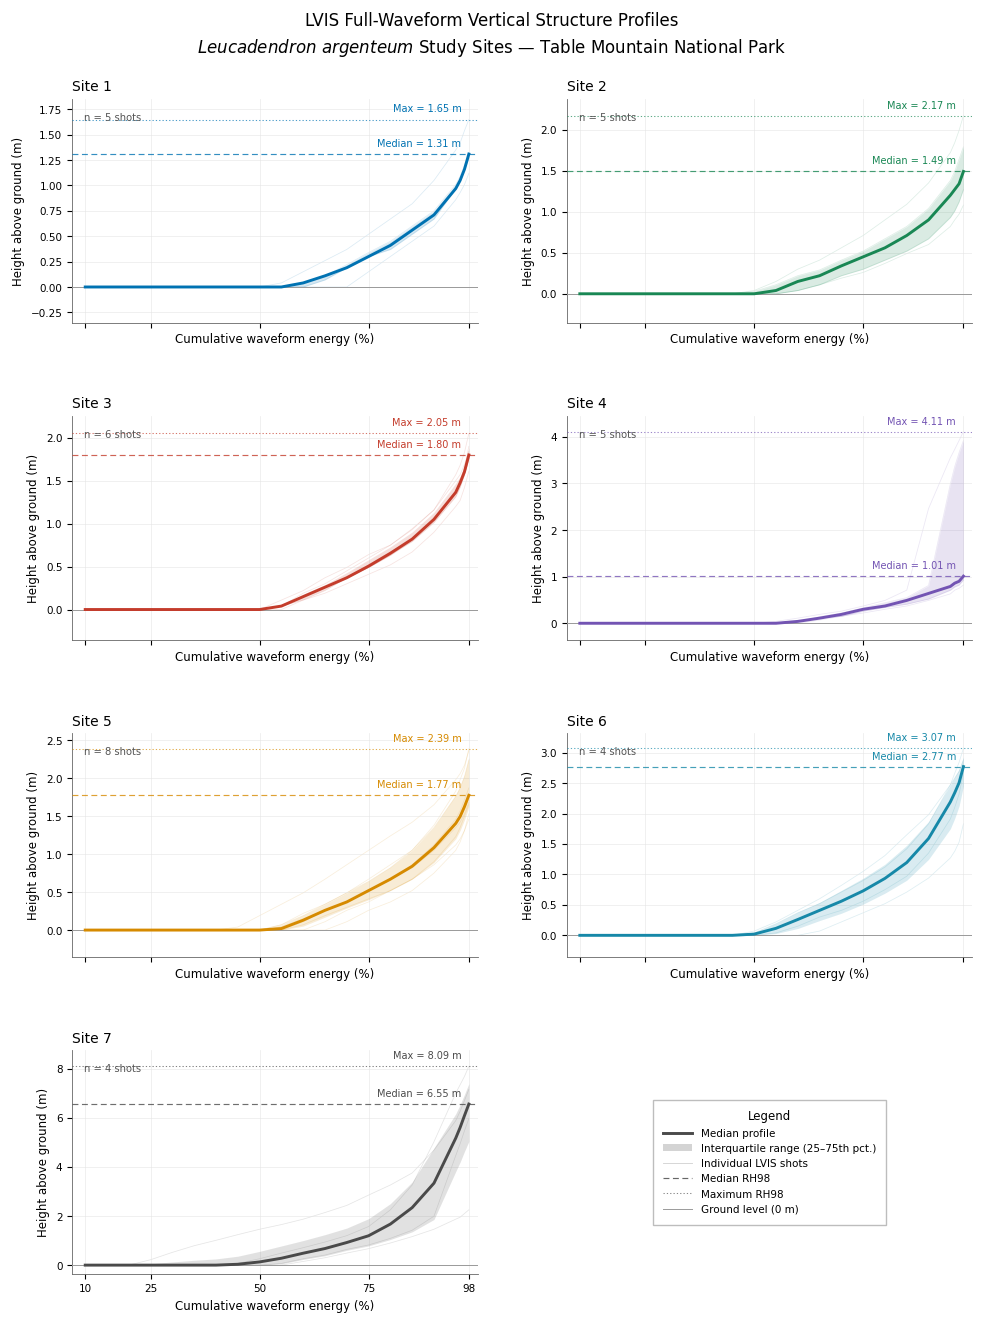


Supporting Information vertical-structure figure saved to:
outputs/01_lvis_pairing2/figures/Fig_SI_LVIS_vertical_structure_profiles.png
outputs/01_lvis_pairing2/figures/Fig_SI_LVIS_vertical_structure_profiles.pdf


In [10]:
# Supporting Information — LVIS full-waveform vertical structure
# --------------------------------------------------------------------
# Uses `joined` directly from the RH98 analysis above.
#
# Negative relative-height values are below the LVIS ground reference.
# They are clipped to 0 m ONLY for this vertical-structure visualisation.
# This produces the intended ground-level segment before each waveform
# profile begins to rise above 0 m.

import re

import matplotlib as mpl
import matplotlib.pyplot as plt

from matplotlib.lines import Line2D
from matplotlib.patches import Patch


# ------------------------------------------------------------------
# Identify the RH metrics available in the quality-filtered `joined`
# object. The Supporting Information figure runs from RH10 to RH98.
# ------------------------------------------------------------------

rh_columns = []

for column in joined.columns:

    match = re.fullmatch(
        r"RH(\d+(?:\.\d+)?)",
        str(column),
    )

    if match is not None:

        cumulative_energy_percent = float(
            match.group(1)
        )

        if (
            cumulative_energy_percent >= 10
            and cumulative_energy_percent <= 98
        ):

            rh_columns.append(
                (
                    column,
                    cumulative_energy_percent,
                )
            )


rh_columns = sorted(
    rh_columns,
    key=lambda item: item[1],
)

if len(rh_columns) < 2:

    raise ValueError(
        "Fewer than two RH metrics between RH10 and RH98 "
        "were found in `joined`."
    )


rh_names = [
    column
    for column, cumulative_energy_percent in rh_columns
]

rh_energy = np.array(
    [
        cumulative_energy_percent
        for column, cumulative_energy_percent in rh_columns
    ],
    dtype=float,
)


print(
    f"Using {len(rh_names)} RH metrics "
    f"from {rh_names[0]} to {rh_names[-1]}."
)

print(
    f"Quality-filtered LVIS shots in `joined`: "
    f"{len(joined):,}"
)


# ------------------------------------------------------------------
# Site colours reproduce the layout supplied for the Supporting
# Information figure.
# ------------------------------------------------------------------

site_colours = {
    "Site 1": "#0072B2",
    "Site 2": "#198754",
    "Site 3": "#C43C2B",
    "Site 4": "#7354B3",
    "Site 5": "#D68A00",
    "Site 6": "#1688A8",
    "Site 7": "#4A4A4A",
}


mpl.rcParams.update({
    "figure.facecolor": "white",
    "savefig.facecolor": "white",
    "savefig.dpi": 400,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.12,
    "font.family": "DejaVu Sans",
    "font.size": 8.5,
    "axes.titlesize": 10,
    "axes.labelsize": 8.5,
    "xtick.labelsize": 7.5,
    "ytick.labelsize": 7.5,
    "legend.fontsize": 7.5,
    "axes.linewidth": 0.6,
    "axes.edgecolor": "#666666",
    "grid.color": "#E3E3E3",
    "grid.linewidth": 0.45,
    "grid.alpha": 0.85,
    "axes.spines.top": False,
    "axes.spines.right": False,
})


# ------------------------------------------------------------------
# Create the 4 × 2 layout:
#
# Site 1 | Site 2
# Site 3 | Site 4
# Site 5 | Site 6
# Site 7 | Legend
# ------------------------------------------------------------------

fig, axes = plt.subplots(
    nrows=4,
    ncols=2,
    figsize=(10.0, 13.5),
    sharex=True,
)

axes = axes.flatten()

sites = [
    "Site 1",
    "Site 2",
    "Site 3",
    "Site 4",
    "Site 5",
    "Site 6",
    "Site 7",
]


for panel_number, site in enumerate(sites):

    ax = axes[
        panel_number
    ]

    colour = site_colours[
        site
    ]

    site_data = (
        joined.loc[
            joined["site"] == site,
            rh_names,
        ]
        .apply(
            pd.to_numeric,
            errors="coerce",
        )
        .copy()
    )

    site_data = site_data.dropna(
        how="all"
    )

    n_shots = len(
        site_data
    )

    if n_shots == 0:

        ax.text(
            0.5,
            0.5,
            "No LVIS shots",
            ha="center",
            va="center",
            transform=ax.transAxes,
            fontsize=9,
        )

        ax.set_title(
            site,
            loc="left",
        )

        continue


    profile_matrix = site_data.to_numpy(
        dtype=float
    )


    # --------------------------------------------------------------
    # Ground filtering for the vertical-structure visualisation.
    #
    # Any finite RH value below 0 m is set to 0 m. Missing values
    # remain missing. This leaves a horizontal segment on the ground
    # line until the waveform profile rises above ground.
    # --------------------------------------------------------------

    profile_matrix = np.where(
        np.isfinite(
            profile_matrix
        ),
        np.maximum(
            profile_matrix,
            0.0,
        ),
        np.nan,
    )


    # --------------------------------------------------------------
    # Individual LVIS shots
    # --------------------------------------------------------------

    for shot_profile in profile_matrix:

        valid_profile = np.isfinite(
            shot_profile
        )

        if valid_profile.sum() >= 2:

            ax.plot(
                rh_energy[
                    valid_profile
                ],
                shot_profile[
                    valid_profile
                ],
                color=colour,
                linewidth=0.55,
                alpha=0.14,
                zorder=1,
            )


    # --------------------------------------------------------------
    # Median and interquartile vertical profiles after the 0 m filter
    # --------------------------------------------------------------

    median_profile = np.nanmedian(
        profile_matrix,
        axis=0,
    )

    lower_quartile = np.nanpercentile(
        profile_matrix,
        25,
        axis=0,
    )

    upper_quartile = np.nanpercentile(
        profile_matrix,
        75,
        axis=0,
    )


    ax.fill_between(
        rh_energy,
        lower_quartile,
        upper_quartile,
        color=colour,
        alpha=0.16,
        linewidth=0,
        zorder=2,
    )

    ax.plot(
        rh_energy,
        median_profile,
        color=colour,
        linewidth=2.1,
        zorder=4,
    )


    # --------------------------------------------------------------
    # RH98 reference values from the same site-level LVIS shots.
    # RH98 has already passed the >= 0 m quality filter upstream.
    # --------------------------------------------------------------

    site_rh98 = pd.to_numeric(
        joined.loc[
            joined["site"] == site,
            "RH98",
        ],
        errors="coerce",
    ).dropna()

    site_rh98 = site_rh98[
        site_rh98 >= 0
    ]

    if site_rh98.empty:

        median_rh98 = np.nan
        maximum_rh98 = np.nan

    else:

        median_rh98 = float(
            site_rh98.median()
        )

        maximum_rh98 = float(
            site_rh98.max()
        )


    # Ground level
    ax.axhline(
        0,
        color="#9A9A9A",
        linewidth=0.70,
        zorder=3,
    )


    if np.isfinite(
        median_rh98
    ):

        ax.axhline(
            median_rh98,
            color=colour,
            linestyle=(0, (5, 3)),
            linewidth=0.85,
            alpha=0.80,
            zorder=3,
        )


    if np.isfinite(
        maximum_rh98
    ):

        ax.axhline(
            maximum_rh98,
            color=colour,
            linestyle=(0, (1.2, 2.0)),
            linewidth=0.75,
            alpha=0.70,
            zorder=3,
        )


    # --------------------------------------------------------------
    # Panel labels
    # --------------------------------------------------------------

    ax.set_title(
        site,
        loc="left",
        pad=6,
    )

    ax.text(
        0.03,
        0.94,
        f"n = {n_shots} shots",
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=7.2,
        color="#555555",
    )


    if np.isfinite(
        maximum_rh98
    ):

        ax.annotate(
            f"Max = {maximum_rh98:.2f} m",
            xy=(
                0.96,
                maximum_rh98,
            ),
            xycoords=(
                "axes fraction",
                "data",
            ),
            xytext=(
                0,
                4,
            ),
            textcoords="offset points",
            ha="right",
            va="bottom",
            fontsize=7,
            color=colour,
        )


    if np.isfinite(
        median_rh98
    ):

        ax.annotate(
            f"Median = {median_rh98:.2f} m",
            xy=(
                0.96,
                median_rh98,
            ),
            xycoords=(
                "axes fraction",
                "data",
            ),
            xytext=(
                0,
                4,
            ),
            textcoords="offset points",
            ha="right",
            va="bottom",
            fontsize=7,
            color=colour,
        )


    # --------------------------------------------------------------
    # Axes
    # --------------------------------------------------------------

    ax.set_xlim(
        7,
        100,
    )

    ax.set_xticks(
        [
            10,
            25,
            50,
            75,
            98,
        ]
    )

    ax.set_xlabel(
        "Cumulative waveform energy (%)"
    )

    ax.set_ylabel(
        "Height above ground (m)"
    )


    # Negative RH values were clipped to ground, so the displayed
    # y-axis begins slightly below zero only to make the 0 m line visible.
    profile_maximum = float(
        np.nanmax(
            profile_matrix
        )
    )

    y_upper = max(
        profile_maximum,
        maximum_rh98
        if np.isfinite(maximum_rh98)
        else 0.0,
    )

    y_padding = max(
        0.20,
        y_upper * 0.08,
    )

    ax.set_ylim(
        -0.35,
        y_upper + y_padding,
    )

    ax.grid(
        True,
        axis="both",
    )


# ------------------------------------------------------------------
# Eighth panel: legend
# ------------------------------------------------------------------

legend_ax = axes[7]

legend_ax.axis(
    "off"
)

legend_items = [
    Line2D(
        [0],
        [0],
        color="#4A4A4A",
        linewidth=2.1,
        label="Median profile",
    ),
    Patch(
        facecolor="#BDBDBD",
        edgecolor="none",
        alpha=0.65,
        label="Interquartile range (25–75th pct.)",
    ),
    Line2D(
        [0],
        [0],
        color="#A0A0A0",
        linewidth=0.65,
        alpha=0.45,
        label="Individual LVIS shots",
    ),
    Line2D(
        [0],
        [0],
        color="#666666",
        linewidth=0.85,
        linestyle=(0, (5, 3)),
        label="Median RH98",
    ),
    Line2D(
        [0],
        [0],
        color="#888888",
        linewidth=0.75,
        linestyle=(0, (1.2, 2.0)),
        label="Maximum RH98",
    ),
    Line2D(
        [0],
        [0],
        color="#9A9A9A",
        linewidth=0.70,
        label="Ground level (0 m)",
    ),
]

legend_ax.legend(
    handles=legend_items,
    title="Legend",
    loc="center",
    frameon=True,
    fancybox=False,
    framealpha=1,
    edgecolor="#BDBDBD",
    facecolor="white",
    borderpad=1.0,
    handlelength=2.8,
)


# ------------------------------------------------------------------
# Figure title and export
# ------------------------------------------------------------------

fig.suptitle(
    "LVIS Full-Waveform Vertical Structure Profiles\n"
    r"$\it{Leucadendron\ argenteum}$ Study Sites — "
    "Table Mountain National Park",
    fontsize=12,
    y=0.995,
    linespacing=1.45,
)

fig.subplots_adjust(
    left=0.08,
    right=0.98,
    bottom=0.06,
    top=0.93,
    hspace=0.42,
    wspace=0.22,
)

figure_dir = (
    C.OUT_DIR
    / "figures"
)

figure_dir.mkdir(
    parents=True,
    exist_ok=True,
)

vertical_structure_png = (
    figure_dir
    / "Fig_SI_LVIS_vertical_structure_profiles.png"
)

vertical_structure_pdf = (
    figure_dir
    / "Fig_SI_LVIS_vertical_structure_profiles.pdf"
)

fig.savefig(
    vertical_structure_png,
    dpi=600,
    bbox_inches="tight",
)

fig.savefig(
    vertical_structure_pdf,
    bbox_inches="tight",
)

plt.show()

print(
    "\nSupporting Information vertical-structure figure saved to:"
)

print(
    vertical_structure_png
)

print(
    vertical_structure_pdf
)


## 9 — Produce the validation figure

The figure is kept separate from the spatial selection and statistical calculations. Changing the analytical buffer therefore changes the data being analysed without requiring changes to the plotting code.

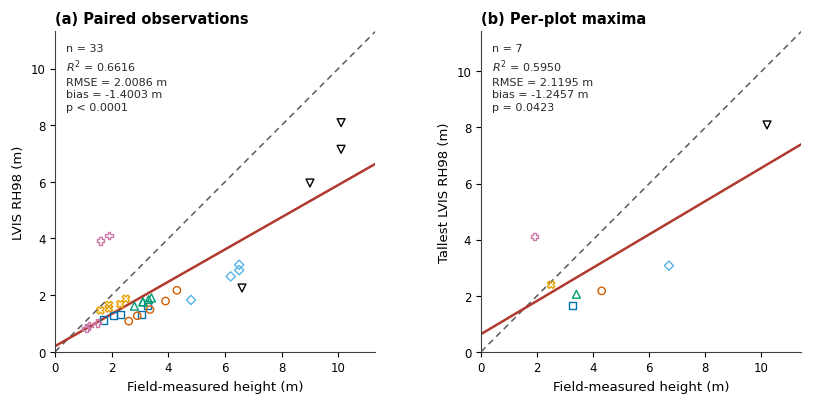

Figure 4 was generated directly from the preceding analysis.

Statistics displayed in panel (a):
n = 33
R² = 0.6616
RMSE = 2.0086 m
bias = -1.4003 m
p = 8.75e-09

Statistics displayed in panel (b):
n = 7
R² = 0.5950
RMSE = 2.1195 m
bias = -1.2457 m
p = 0.04225


In [11]:
# Figure 4 — LVIS RH98 versus field-measured tree height
# This figure is a direct visualisation of the analysis carried out above.

# It uses:
#         primary                  -> the observations used in the paired analysis
#         maxima                   -> the observations used in the plot-maxima analysis
#         results["paired"]        -> statistics already calculated above
#         results["plot_maxima"]   -> statistics already calculated above

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np


# Figure appearance

mpl.rcParams.update({
    "figure.facecolor": "white",
    "savefig.facecolor": "white",
    "savefig.dpi": 400,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.12,
    "font.family": "DejaVu Sans",
    "font.size": 9,
    "axes.titlesize": 10.5,
    "axes.labelsize": 9.5,
    "xtick.labelsize": 8.5,
    "ytick.labelsize": 8.5,
    "legend.fontsize": 8,
    "axes.grid": False,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.linewidth": 0.8,
    "axes.edgecolor": "#3F3F3F",
})


# Marker used for each field plot

STYLE = {
    1: ("s", "#0072B2", 26),    # square
    2: ("o", "#D55E00", 28),    # circle
    3: ("^", "#009E73", 32),    # triangle
    4: ("P", "#CC79A7", 30),    # plus
    5: ("X", "#E69F00", 28),    # cross
    6: ("D", "#56B4E9", 22),    # diamond
    7: ("v", "#000000", 32),    # inverted triangle
}

MARKER_EDGE_WIDTH = 1.0


# Convert the plot identifier into the number used by STYLE
def site_number(value):
    """
    Convert common plot labels into an integer.

    Examples:
        1        -> 1
        1.0      -> 1
        "1"      -> 1
        "Site 1" -> 1
    """
    # First try to interpret the value directly as a number.
    try:
        number = float(value)
        if np.isfinite(number):
            return int(number)
    except (TypeError, ValueError):
        pass

    # If the value is text such as "Site 3", extract the first number.
    text = str(value)
    digits = ""
    decimal_found = False
    for character in text:
        if character.isdigit():
            digits += character
        elif character == "." and digits and not decimal_found:
            decimal_found = True
        elif digits:
            break
    if digits:
        return int(digits)
    return value


# Draw one panel
def draw_panel(ax, x, y, sites, stat, title, y_label):
    """
    Draw one panel using observations and statistics already generated above.

    x and y are supplied directly from the analysis data frame.
    stat is supplied directly from the `results` dictionary.
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    sites = np.asarray(sites)
    # Remove missing values only for plotting.
    # The analysis has already determined which observations belong here.
    ok = np.isfinite(x) & np.isfinite(y)
    x = x[ok]
    y = y[ok]
    sites = sites[ok]
    if len(x) == 0:
        raise ValueError(f"No valid observations available for: {title}")
    # Convert the plot identifiers to the numbers used by STYLE.
    sites = np.array(
        [site_number(site) for site in sites],
        dtype=object
    )
    # Use the same range for both axes so that the 1:1 line
    # represents exact agreement between field and LVIS height.
    upper = float(np.max(np.r_[x, y]) * 1.12)
    lim = (0.0, upper)
    xx = np.linspace(
        lim[0],
        lim[1],
        200
    )
    # Regression line
    regression_y = (
        stat["intercept"]
        + stat["slope"] * xx
    )
    ax.plot(
        xx,
        regression_y,
        color="#B03A2E",
        linewidth=1.8,
        zorder=2,
    )
    # 1:1 line
    ax.plot(
        lim,
        lim,
        linestyle=(0, (4, 3)),
        color="#5A5A5A",
        linewidth=1.1,
        zorder=1,
    )

    # Observed points
    for site in sorted(set(sites)):
        # Check that the plot number exists in the defined style table.
        # This prevents an unexpected label from silently becoming a
        # black circle.
        if site not in STYLE:
            raise ValueError(
                f"Plot identifier {site!r} was not found in STYLE. "
                f"Available plot numbers are: {list(STYLE.keys())}"
            )
        marker, colour, size = STYLE[site]
        selected = sites == site
        ax.scatter(
            x[selected],
            y[selected],
            marker=marker,
            s=size,
            facecolors="none",
            edgecolors=colour,
            linewidths=MARKER_EDGE_WIDTH,
            zorder=3,
        )
    # Axis limits and aspect ratio
    ax.set_xlim(lim)
    ax.set_ylim(lim)
    ax.set_aspect(
        "equal",
        adjustable="box"
    )
    # Axis labels
    ax.set_xlabel(
        "Field-measured height (m)"
    )
    ax.set_ylabel(
        y_label
    )
    # Panel title
    ax.set_title(
        title,
        loc="left",
        fontweight="semibold",
        pad=6
    )
    # Statistics displayed on the figure

    # Only the requested five statistics are shown:
    #         n
    #         R²
    #         RMSE
    #         bias
    #         p
    p_value = stat["p"]
    
    # Display very small p-values in a readable form.
    if p_value < 0.0001:
        p_text = "p < 0.0001"
    else:
        p_text = f"p = {p_value:.4f}"
    statistics_text = (
        f"n = {int(stat['n'])}\n"
        f"$R^2$ = {stat['r2']:.4f}\n"
        f"RMSE = {stat['RMSE_m']:.4f} m\n"
        f"bias = {stat['bias_m']:+.4f} m\n"
        f"{p_text}"
    )
    # Place the statistics inside the panel.
    ax.text(
        0.035,
        0.965,
        statistics_text,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=8.0,
        linespacing=1.35,
        color="#2A2A2A",
    )

# 1. Retrieve the results generated by the analysis
paired_stats = results["paired"]
maxima_stats = results["plot_maxima"]

# 2. Prepare the two datasets
# Panel (a): paired observations
# These are the exact observations used to calculate results["paired"].
paired_x = primary["field_height_m"]
paired_y = primary["lvis_rh98_m"]
paired_sites = primary["site"]


# Panel (b): plot-level maxima
# These are the exact observations used to calculate
# results["plot_maxima"].
maxima_x = maxima["field_max_m"]
maxima_y = maxima["lvis_max_rh98_m"]
maxima_sites = maxima["site"]


# 3. Create the figure
fig, axes = plt.subplots(
    1,
    2,
    figsize=(8.2, 4.15)
)
# Panel (a): paired observations
draw_panel(
    ax=axes[0],
    x=paired_x,
    y=paired_y,
    sites=paired_sites,
    stat=paired_stats,
    title="(a) Paired observations",
    y_label="LVIS RH98 (m)",
)
# Panel (b): plot-level maxima
draw_panel(
    ax=axes[1],
    x=maxima_x,
    y=maxima_y,
    sites=maxima_sites,
    stat=maxima_stats,
    title="(b) Per-plot maxima",
    y_label="Tallest LVIS RH98 (m)",
)

# 4. Final layout and export
fig.subplots_adjust(
    left=0.075,
    right=0.985,
    bottom=0.13,
    top=0.92,
    wspace=0.33,
)
# Save the figure using the existing output directory.
figure_dir = C.OUT_DIR / "figures"
figure_dir.mkdir(
    parents=True,
    exist_ok=True
)


fig.savefig(figure_dir / "fig4_heights.png")
fig.savefig(figure_dir / "fig4_heights.pdf")
plt.show()


# 5. Print the exact statistics used in the figure
print("Figure 4 was generated directly from the preceding analysis.")
print()

print("Statistics displayed in panel (a):")
print(f"n = {int(paired_stats['n'])}")
print(f"R² = {paired_stats['r2']:.4f}")
print(f"RMSE = {paired_stats['RMSE_m']:.4f} m")
print(f"bias = {paired_stats['bias_m']:+.4f} m")
print(f"p = {paired_stats['p']:.4g}")
print()

print("Statistics displayed in panel (b):")
print(f"n = {int(maxima_stats['n'])}")
print(f"R² = {maxima_stats['r2']:.4f}")
print(f"RMSE = {maxima_stats['RMSE_m']:.4f} m")
print(f"bias = {maxima_stats['bias_m']:+.4f} m")
print(f"p = {maxima_stats['p']:.4g}")

The end. Thank you for reading and following instructions.